In [96]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

colors = {
    'Curtis Sliwa': '#1f77b4',  # Azul
    'Eric Adams': '#ff7f0e',  # Laranja
    'Andrew Cuomo': '#2ca02c',  # Verde
    'Zohran Mamdani': '#d62728'  # Vermelho
}

# Como os debates influenciaram as eleições para a prefeitura de Nova York de 2025?

A corrida eleitoral de 2025 para a prefeitura de Nova York foi uma das mais imprevisíveis e históricas das últimas décadas. O cenário inicial foi marcado pela turbulência em torno do então prefeito Eric Adams, que retirou sua candidatura à reeleição em setembro de 2025, abrindo um vácuo de poder na cidade.

Aproveitando a ausência do candidato, o ex-governador de Nova York, Andrew Cuomo, disparou inicialmente como o grande favorito em sua tentativa de retorno político. No entanto, o cenário sofreu uma reviravolta drástica quando Zohran Mamdani, um deputado estadual de 34 anos pelo Queens, o derrotou nas primárias do Partido Democrata. Recusando-se a aceitar a derrota, Cuomo decidiu concorrer na eleição geral como um candidato independente, fragmentando a base eleitoral.

A eleição geral de novembro se configurou em uma disputa de alto nível entre três frentes: Zohran Mamdani (Democrata), Andrew Cuomo (Independente) e Curtis Sliwa (Republicano). Mamdani começou a campanha geral sendo visto por parte do eleitorado como inexperiente e "azarão" frente à forte máquina política, capital e reconhecimento midiático de Cuomo.

Foi nesse ambiente de alta incerteza que os debates eleitorais de outubro de 2025 (realizados nos dias 16 e 22) assumiram um papel de "ponto de inflexão". O objetivo deste relatório é investigar, através da inteligência coletiva e da movimentação financeira no Polymarket, como a percepção de vitória se alterou nesses momentos-chave. A hipótese central é que o bom desempenho de Mamdani nos debates foi o catalisador que permitiu sua ultrapassagem sobre os adversários, consolidando o favoritismo que culminou em sua vitória nas urnas em 4 de novembro, com mais de 50% dos votos.

## Evolução das probabilidades

Para começar nossa análise vamos analisar como favoritismo de cada candidato mudou ao longo do período eleitoral.

Primeira Query:

SELECT 
  market_id, 
  trade_date,
  CASE
    WHEN market_id = '538932' THEN 'Zohran Mamdani'
    WHEN market_id = '538929' THEN 'Andrew Cuomo'
    WHEN market_id = '538930' THEN 'Curtis Sliwa'
    WHEN market_id = '538928' THEN 'Eric Adams'
  END AS candidato,
  avg_trade_price as probabilidade_media,
  daily_usd_volume
FROM `even-continuity-441808-j0.polymarket_mart.v_market_daily`
WHERE market_id IN ('538932', '538929', '538930', '538928')
ORDER BY trade_date, candidato;


In [97]:
dados_gerais = pd.read_csv(r'C:\Users\felip\ufrj-analytica-training\entregaveis\banco_de_dados_2\felipe_indio\dados\job_C4-MHv5O3sn57kQnOrLv1O1ViQDh.csv')
dados_gerais['trade_date'] = pd.to_datetime(dados_gerais['trade_date'])
dados_gerais = dados_gerais.sort_values(by='trade_date', ascending=True)
dados_gerais.head()

,market_id,trade_date,candidato,probabilidade_media,daily_usd_volume,daily_trade_count,rolling_7d_avg_volume,ticket_medio_diario
0,538929,2025-04-22,Andrew Cuomo,0.405714,211.95,14,211.95,15.139286
1,538930,2025-04-22,Curtis Sliwa,0.316667,18.67,3,18.67,6.223333
2,538928,2025-04-22,Eric Adams,0.015000,0.11,2,0.11,0.055000
3,538932,2025-04-22,Zohran Mamdani,0.086667,1.05,3,1.05,0.350000
4,538929,2025-04-23,Andrew Cuomo,0.635000,193.35,4,202.65,48.337500


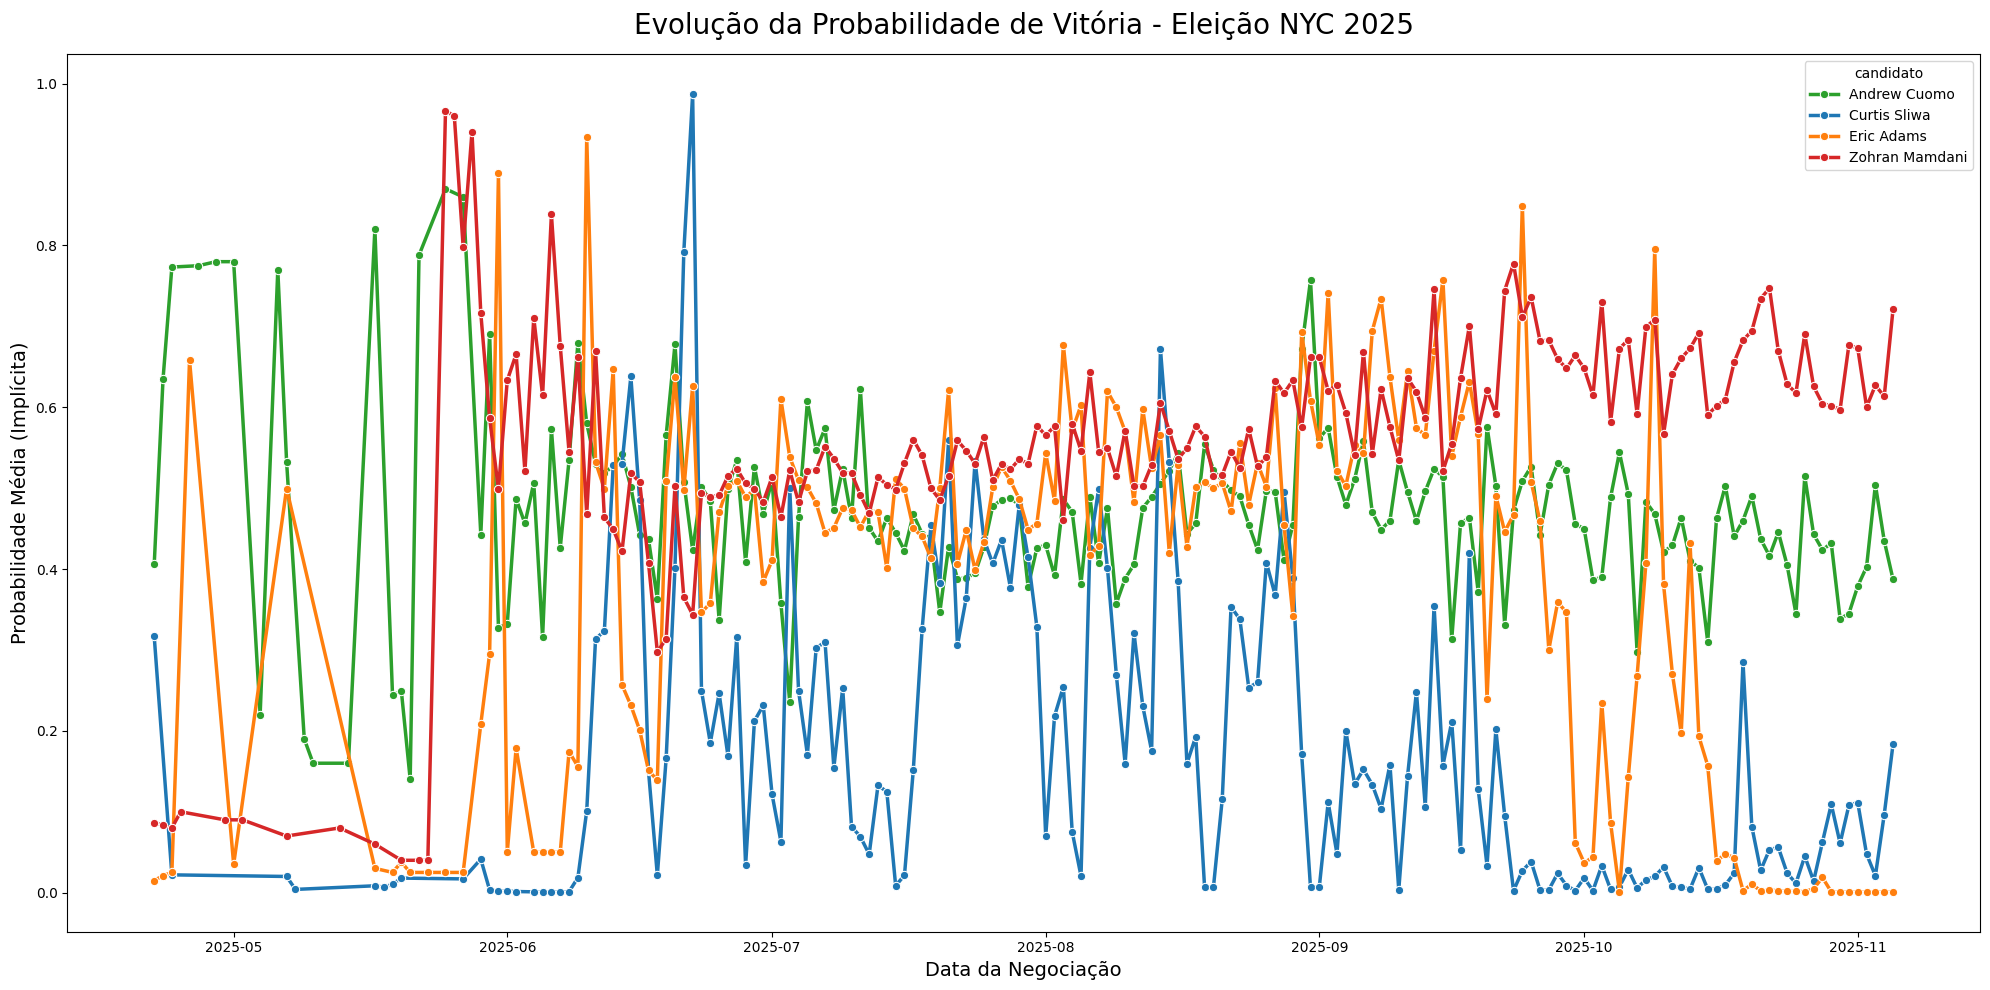

In [98]:
plt.figure(figsize=(20, 10))
sns.lineplot(data=dados_gerais, x='trade_date', y='probabilidade_media', hue='candidato', marker='o', palette=colors, linewidth=2.5)

plt.title('Evolução da Probabilidade de Vitória - Eleição NYC 2025', fontsize=20, pad=15)
plt.xlabel('Data da Negociação', fontsize=14)
plt.ylabel('Probabilidade Média (Implícita)', fontsize=14)
plt.tight_layout()
plt.show()

Como o polymarket é um mercado muito instável, o gráfico ficou um pouco confuso. Então eu irei calcular a média semanal de cada probabilidade e plotá-las. Além disso irei marcar no gráfico a data dos dois deabtes (realizados nos dias 16 e 22 de outubro).

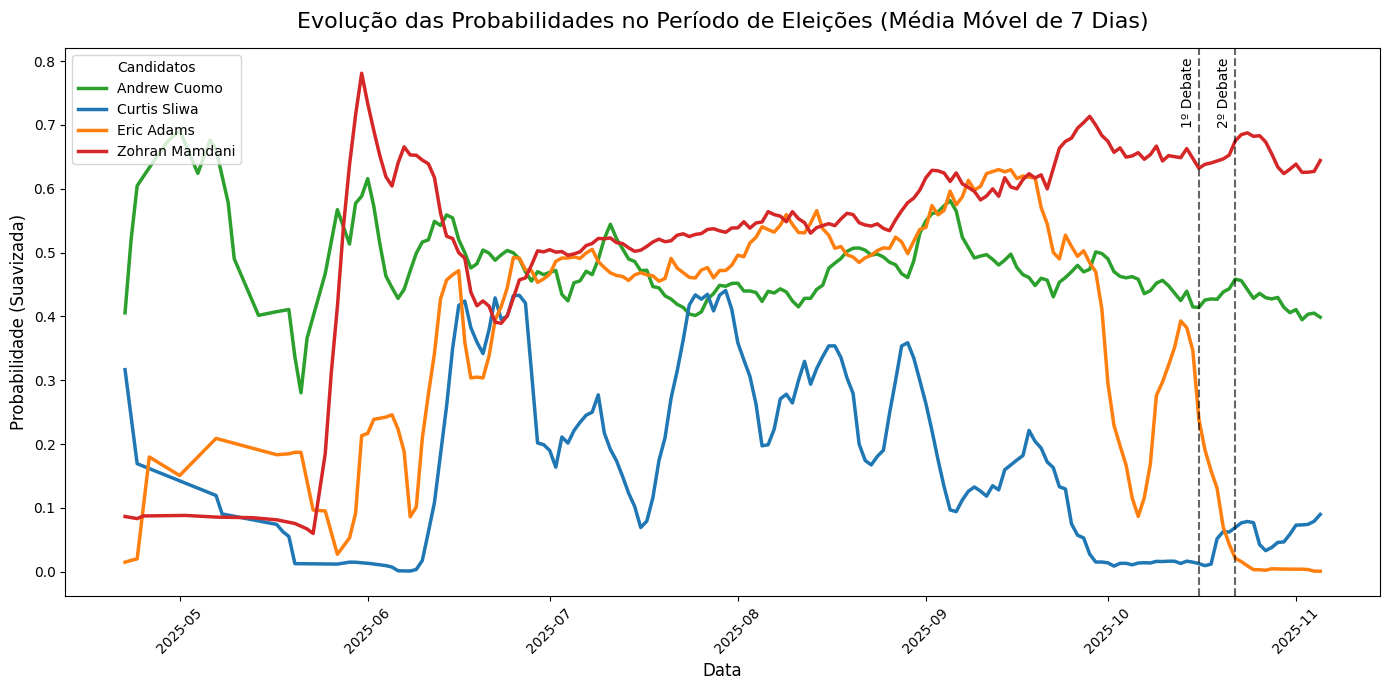

In [88]:
dados_gerais['prob_suavizada'] = dados_gerais.groupby('candidato')['probabilidade_media'].transform(lambda x: x.rolling(window=7, min_periods=1).mean())

plt.figure(figsize=(14, 7))
sns.lineplot(data=dados_gerais, x='trade_date', y='prob_suavizada', hue='candidato', linewidth=2.5, palette=colors)

#1° Debate
plt.axvline(x=pd.to_datetime('2025-10-16'), color='black', linestyle='--', alpha=0.6)
plt.text(pd.to_datetime('2025-10-13'), 0.75, '1º Debate', color='black', rotation=90, va='center')

# 2º Debate
plt.axvline(x=pd.to_datetime('2025-10-22'), color='black', linestyle='--', alpha=0.6)
plt.text(pd.to_datetime('2025-10-19'), 0.75, '2º Debate', color='black', rotation=90, va='center')

plt.title('Evolução das Probabilidades no Período de Eleições (Média Móvel de 7 Dias)', fontsize=16, pad=15)
plt.xlabel('Data', fontsize=12)
plt.ylabel('Probabilidade (Suavizada)', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Candidatos', loc='upper left')
plt.tight_layout()
plt.show()

Analisando o primeiro gráfico friamente, os debates não pareceram ter causado tanto efeito no favoritismo de Zohran Mamdani, pois ele já estava com larga vantagem antes mesmo deles ocorrerem, no entanto vamos continuar investigando para ver o que pode ter causado essa reviravolta tão grande.

Vamos analisar dois outros importantes cenários dessas eleições, as primárias democratas em que Zohran Mandani derrotou Andrew Cuomo e a desistência de Eric Adams.

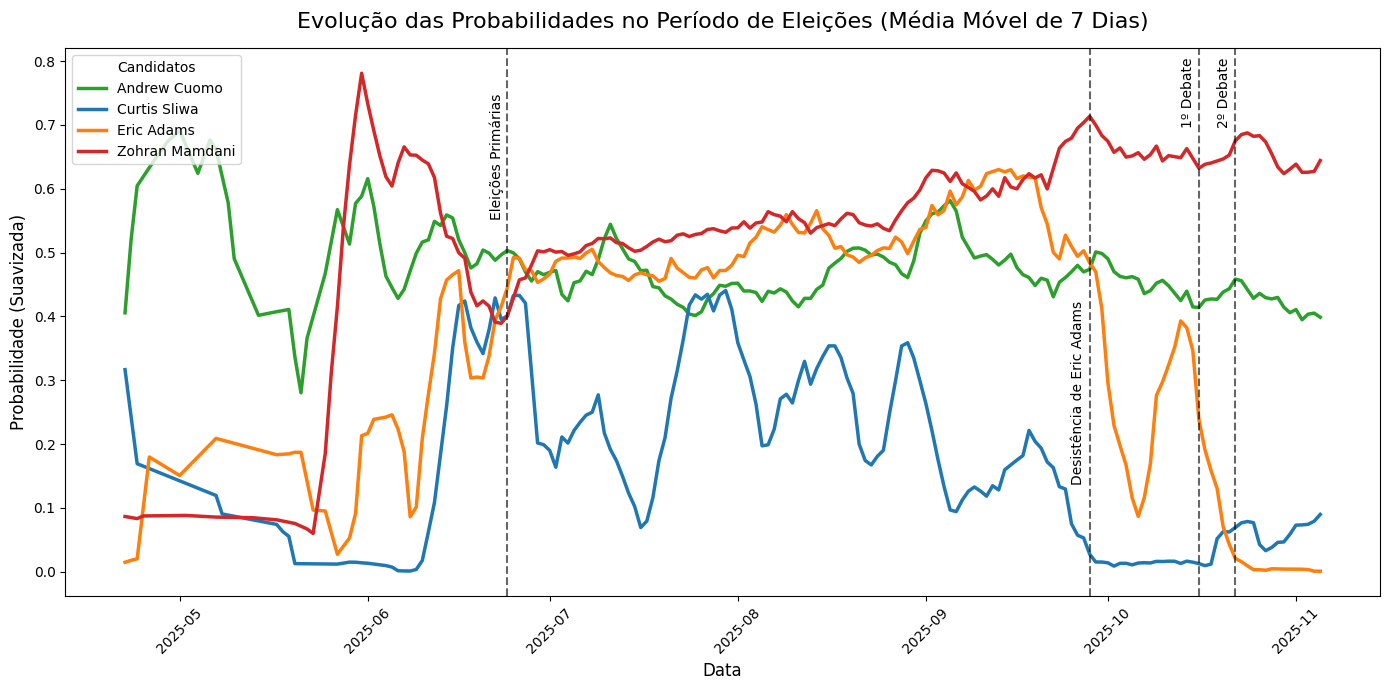

In [89]:
plt.figure(figsize=(14, 7))
sns.lineplot(data=dados_gerais, x='trade_date', y='prob_suavizada', hue='candidato', linewidth=2.5, palette=colors)

#1° Debate
plt.axvline(x=pd.to_datetime('2025-10-16'), color='black', linestyle='--', alpha=0.6)
plt.text(pd.to_datetime('2025-10-13'), 0.75, '1º Debate', color='black', rotation=90, va='center')

# 2º Debate
plt.axvline(x=pd.to_datetime('2025-10-22'), color='black', linestyle='--', alpha=0.6)
plt.text(pd.to_datetime('2025-10-19'), 0.75, '2º Debate', color='black', rotation=90, va='center')

#Eleições Primárias
plt.axvline(x=pd.to_datetime('2025-6-24'), color='black', linestyle='--', alpha=0.6)
plt.text(pd.to_datetime('2025-6-21'), 0.65, 'Eleições Primárias', color='black', rotation=90, va='center')

#Desistência do Eric Adams
plt.axvline(x=pd.to_datetime('2025-9-28'), color='black', linestyle='--', alpha=0.6)
plt.text(pd.to_datetime('2025-9-25'), 0.28, 'Desistência de Eric Adams', color='black', rotation=90, va='center')

plt.title('Evolução das Probabilidades no Período de Eleições (Média Móvel de 7 Dias)', fontsize=16, pad=15)
plt.xlabel('Data', fontsize=12)
plt.ylabel('Probabilidade (Suavizada)', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Candidatos', loc='upper left')
plt.tight_layout()
plt.show()

Aqui podemos ver que esses dois novos eventos influenciaram de forma significativa as probabilidades. Após as eleições primárias, Zohran Mamdani manteve seu favoritismo estabilizado até o fim das eleições. E após a desistência de Eric Adams, a probabilidade do mesmo ganhar reduziu drasticamente até chegar a zero.

## Ticket Médio Diário

Agora vamos analisar uma nova variável, ticket médio diário, que é o valor médio gasto em cada candidato durante todos os dias. Assim podemos checar se em algum dia houve uma explosão de valores ou um aumento do número de apostas. 

Um ticket baixo significa muitas apostas de baixo valor, enquanto um pico de ticket alto significa poucas transações de alto valor, ou simplesmente um aumento no valor das apostas. 

Segunda query: 

SELECT 
  market_id, 
  trade_date,
  CASE
    WHEN market_id = '538932' THEN 'Zohran Mamdani'
    WHEN market_id = '538929' THEN 'Andrew Cuomo'
    WHEN market_id = '538930' THEN 'Curtis Sliwa'
    WHEN market_id = '538928' THEN 'Eric Adams'
  END AS candidato,
  avg_trade_price as probabilidade_media,
  daily_usd_volume,
  daily_trade_count,
  daily_usd_volume/daily_trade_count as ticket_medio_diario
FROM `even-continuity-441808-j0.polymarket_mart.v_market_daily`
WHERE market_id IN ('538932', '538929', '538930', '538928')
ORDER BY trade_date ASC, candidato;


In [59]:
ticket_medio = pd.read_csv(r'C:\Users\felip\ufrj-analytica-training\entregaveis\banco_de_dados_2\felipe_indio\dados\ticket medio diario.csv')
ticket_medio['trade_date'] = pd.to_datetime(ticket_medio['trade_date'])
ticket_medio = ticket_medio.sort_values(by='trade_date', ascending=True)
ticket_medio

,market_id,trade_date,candidato,probabilidade_media,daily_usd_volume,daily_trade_count,ticket_medio_diario
0,538929,2025-04-22,Andrew Cuomo,0.405714,211.95,14,15.139286
1,538930,2025-04-22,Curtis Sliwa,0.316667,18.67,3,6.223333
2,538928,2025-04-22,Eric Adams,0.015000,0.11,2,0.055000
3,538932,2025-04-22,Zohran Mamdani,0.086667,1.05,3,0.350000
4,538929,2025-04-23,Andrew Cuomo,0.635000,193.35,4,48.337500
...,...,...,...,...,...,...,...
692,538930,2025-11-04,Curtis Sliwa,0.096581,280059.01,752,372.418896
696,538930,2025-11-05,Curtis Sliwa,0.183761,47243.85,71,665.406338
697,538928,2025-11-05,Eric Adams,0.001000,45.00,19,2.368421
695,538929,2025-11-05,Andrew Cuomo,0.387120,1918537.37,1943,987.409866


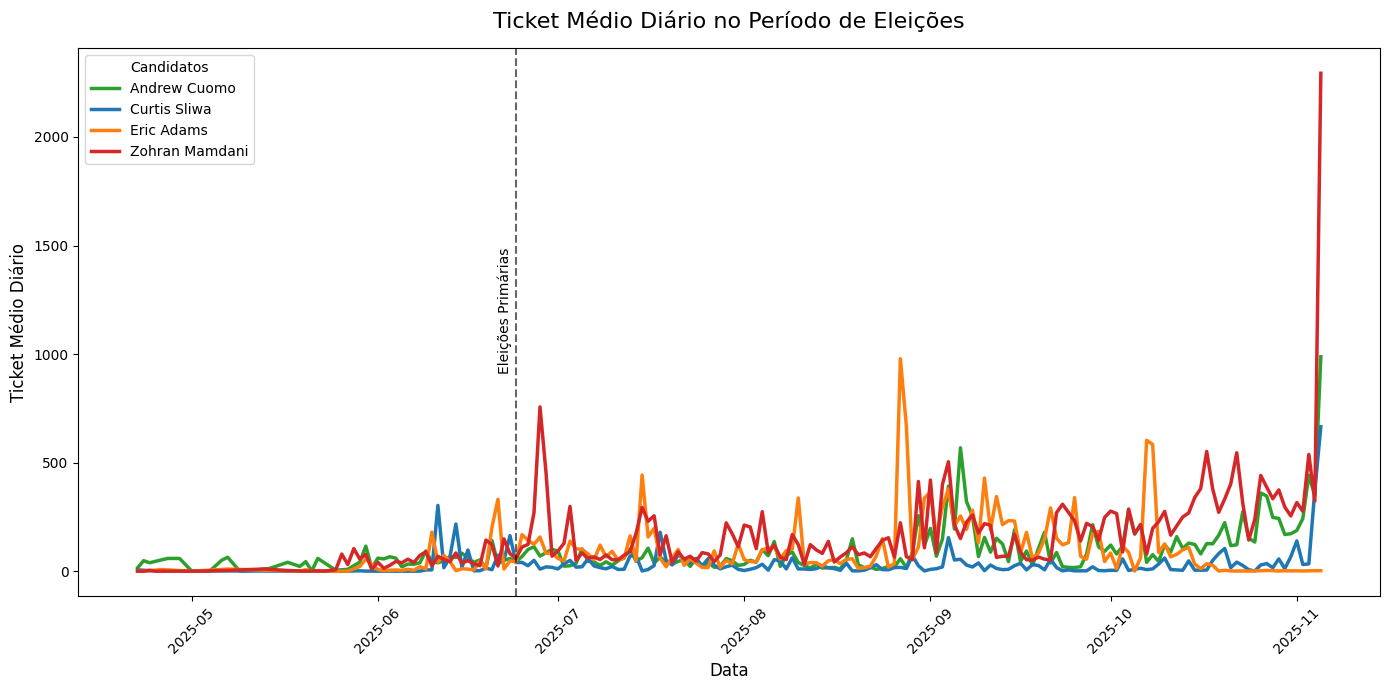

In [90]:
plt.figure(figsize=(14, 7))
sns.lineplot(data=ticket_medio, x='trade_date', y='ticket_medio_diario', hue='candidato', linewidth=2.5, palette=colors)

#Eleições Primárias
plt.axvline(x=pd.to_datetime('2025-6-24'), color='black', linestyle='--', alpha=0.6)
plt.text(pd.to_datetime('2025-6-21'), 1200, 'Eleições Primárias', color='black', rotation=90, va='center')

plt.title('Ticket Médio Diário no Período de Eleições', fontsize=16, pad=15)
plt.xlabel('Data', fontsize=12)
plt.ylabel('Ticket Médio Diário', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Candidatos', loc='upper left')
plt.tight_layout()
plt.show()

Após as eleições primárias, houve um aumento significativo no valor das aspostas em Zohran Mamdani. Outro fato curioso, é que o ticket médio nas apostas em Eric Adams aumentou consideravelmente após sua desistência, o que pode ter ocasionado isso é que muitas pessoas devem ter apostado um valor alto na sua derrota, pois ambas as apostas (vitória ou derrota do candidato) aumentam o volume de dólares gastos.

## Volatilidade por candidato

Na próxima etapa, vamos olhar a distribuição da volatilidade por candidato:

Terceira query:

SELECT 
    market_id, 
  trade_date,
  CASE
    WHEN market_id = '538932' THEN 'Zohran Mamdani'
    WHEN market_id = '538929' THEN 'Andrew Cuomo'
    WHEN market_id = '538930' THEN 'Curtis Sliwa'
    WHEN market_id = '538928' THEN 'Eric Adams'
  END AS candidato,
  avg_price_deviation,
  price_volatility
FROM `even-continuity-441808-j0.polymarket_mart.daily_price_deviation` 
WHERE market_id IN ('538932', '538929', '538930', '538928')
ORDER BY trade_date DESC, candidato;

In [76]:
volatilidade_df = pd.read_csv(r'C:\Users\felip\ufrj-analytica-training\entregaveis\banco_de_dados_2\felipe_indio\dados\volatilidade.csv')
volatilidade_df['trade_date'] = pd.to_datetime(volatilidade_df['trade_date'])
volatilidade_df = volatilidade_df.sort_values(by='trade_date', ascending=True)
volatilidade_df

,market_id,trade_date,candidato,avg_price_deviation,price_volatility
698,538932,2025-04-22,Zohran Mamdani,0.000000,0.005774
695,538929,2025-04-22,Andrew Cuomo,0.342857,0.290747
697,538928,2025-04-22,Eric Adams,0.000000,0.000000
696,538930,2025-04-22,Curtis Sliwa,0.286667,0.531162
692,538929,2025-04-23,Andrew Cuomo,0.140000,0.276707
...,...,...,...,...,...
4,538929,2025-11-04,Andrew Cuomo,0.356391,0.416834
3,538932,2025-11-05,Zohran Mamdani,0.258866,0.426620
2,538928,2025-11-05,Eric Adams,0.000000,0.000000
1,538930,2025-11-05,Curtis Sliwa,0.182732,0.388708


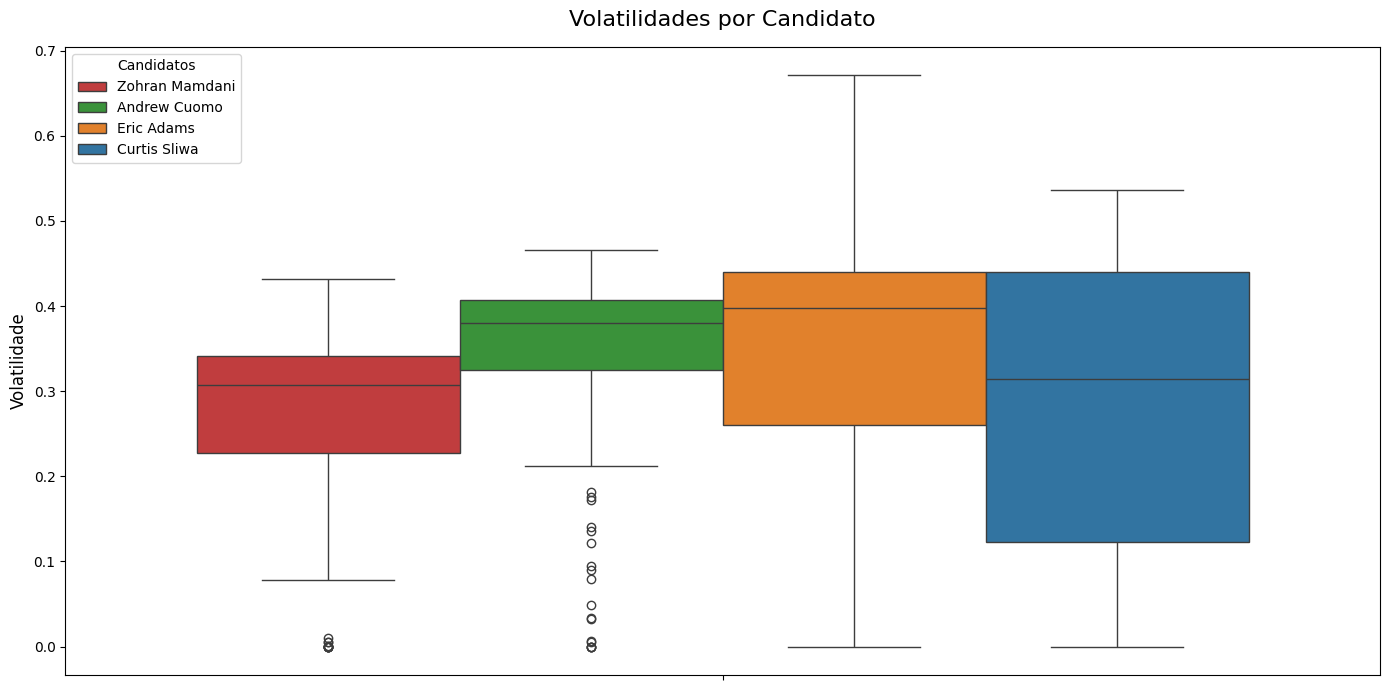

In [ ]:
plt.figure(figsize=(14, 7))
sns.boxplot(data=volatilidade_df, y='price_volatility', hue='candidato', palette=colors)

plt.title('Volatilidade por Candidato', fontsize=16, pad=15)
plt.ylabel('Volatilidade', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Candidatos', loc='upper left')
plt.tight_layout()
plt.show()

## Alertas

Quarta Query:

WITH BaseCandidatos AS (
    -- Etapa 1: Filtra o mercado escolhido e nomeia os candidatos
    SELECT
        trade_date,
        CASE
            WHEN market_id = '538932' THEN 'Zohran Mamdani'
            WHEN market_id = '538929' THEN 'Andrew Cuomo'
            WHEN market_id = '538930' THEN 'Curtis Sliwa'
            WHEN market_id = '538928' THEN 'Eric Adams'
        END AS candidato,
        avg_trade_price,
        daily_usd_volume,
        rolling_7d_avg_volume
    FROM `even-continuity-441808-j0.polymarket_mart.v_market_daily`
    WHERE market_id IN ('538932', '538929', '538930', '538928')
),
CalculoJanela AS (
    -- Etapa 2: Utiliza a função LAG para buscar o preço exato do dia anterior
    SELECT
        trade_date,
        candidato,
        avg_trade_price AS preco_atual,
        LAG(avg_trade_price) OVER (
            PARTITION BY candidato 
            ORDER BY trade_date
        ) AS preco_anterior,
        daily_usd_volume,
        rolling_7d_avg_volume
    FROM BaseCandidatos
),
MapeamentoVariaveis AS (
    -- Etapa 3: Calcula as proporções e diferenças
    SELECT
        trade_date,
        candidato,
        preco_atual,
        preco_anterior,
        daily_usd_volume,
        rolling_7d_avg_volume,
        (daily_usd_volume / NULLIF(rolling_7d_avg_volume, 0)) AS multiplicador_volume,
        ABS(preco_atual - preco_anterior) AS variacao_preco
    FROM CalculoJanela
)
-- Etapa 4: Retorna apenas os registros que satisfazem pelo menos uma das regras de alerta
SELECT
    trade_date,
    candidato,
    preco_atual,
    preco_anterior,
    variacao_preco,
    daily_usd_volume,
    rolling_7d_avg_volume,
    ROUND(multiplicador_volume, 2) AS multiplicador_volume_atual,
    
    -- Classifica o tipo de alerta que foi disparado no dia
    CASE
        WHEN variacao_preco >= 0.30 AND multiplicador_volume >= 4.0 
             THEN 'Alerta Duplo: Preço variou > 0.30 e Volume > 4x'
             
        WHEN variacao_preco >= 0.30 
             THEN 'Alerta de Preço: Variação > 0.30'
             
        WHEN multiplicador_volume >= 4.0 
             THEN 'Alerta de Volume: Picos > 4x a Média'
             
    END AS tipo_alerta

FROM MapeamentoVariaveis
WHERE variacao_preco >= 0.30
   OR multiplicador_volume >= 4.0
   
ORDER BY trade_date DESC, candidato;

Essa query ativa 2 alertas:
- Quando a probabilidade varia 0.30 do dia anterior.
- Quando o volume negociado em um dia é 4x o volume médio negociado na semana.

In [101]:
alertas_df = pd.read_csv(r'C:\Users\felip\ufrj-analytica-training\entregaveis\banco_de_dados_2\felipe_indio\dados\alertas.csv')
alertas_df['trade_date'] = pd.to_datetime(alertas_df['trade_date'])
alertas_df.head()

,trade_date,candidato,preco_atual,preco_anterior,variacao_preco,daily_usd_volume,rolling_7d_avg_volume,multiplicador_volume_atual,tipo_alerta
0,2025-10-10,Eric Adams,0.381181,0.795120,0.413939,65263.62,108089.885714,0.60,Alerta de Preço: Variação > 0.30
1,2025-10-09,Eric Adams,0.795120,0.407353,0.387767,32862.04,105652.241429,0.31,Alerta de Preço: Variação > 0.30
2,2025-10-07,Eric Adams,0.267385,0.142487,0.124898,360465.57,68222.610000,5.28,Alerta de Volume: Picos > 4x a Média
3,2025-09-28,Andrew Cuomo,0.530847,0.504506,0.026340,215939.73,48820.822857,4.42,Alerta de Volume: Picos > 4x a Média
4,2025-09-28,Curtis Sliwa,0.023884,0.003497,0.020387,6582.18,1378.551429,4.77,Alerta de Volume: Picos > 4x a Média


In [103]:
alertas_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   trade_date                  54 non-null     datetime64[ns]
 1   candidato                   54 non-null     object        
 2   preco_atual                 54 non-null     float64       
 3   preco_anterior              54 non-null     float64       
 4   variacao_preco              54 non-null     float64       
 5   daily_usd_volume            54 non-null     float64       
 6   rolling_7d_avg_volume       54 non-null     float64       
 7   multiplicador_volume_atual  54 non-null     float64       
 8   tipo_alerta                 54 non-null     object        
dtypes: datetime64[ns](1), float64(6), object(2)
memory usage: 3.9+ KB


In [102]:
alertas_df.value_counts('tipo_alerta')

tipo_alerta
Alerta de Preço: Variação > 0.30                   29
Alerta de Volume: Picos > 4x a Média               22
Alerta Duplo: Preço variou > 0.30 e Volume > 4x     3
Name: count, dtype: int64

O resultado dos alertas foram 54 casos no total, com:

29 alertas de preço, 22 alertas de volume e 3 alertas duplos.